## Visualizing Financial Time Series

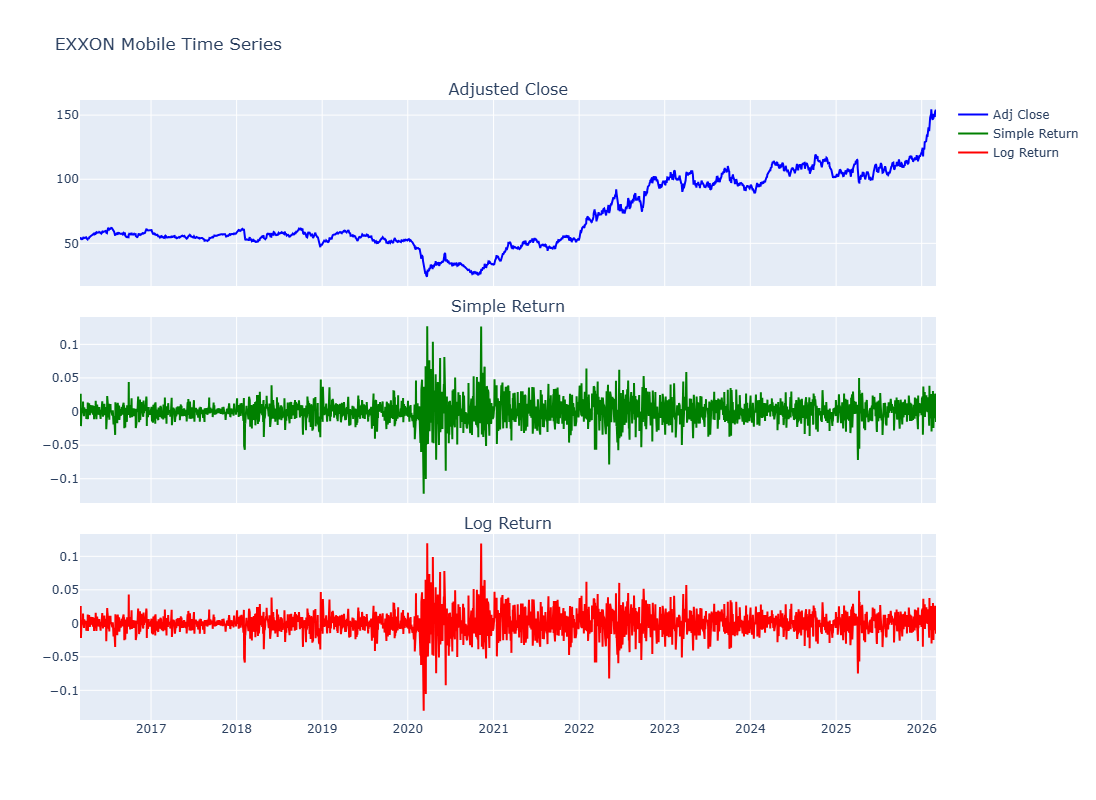

In [6]:
#1.Import libraries

import pandas as pd 
import numpy as np 
import yfinance as yf
from datetime import datetime
from dateutil.relativedelta import relativedelta
#2. Dates Variables 
start_date = datetime.now()- relativedelta(years=10)
end_date   = datetime.now()
#3. Descargue los datos y mantenga solo los precios de cierre ajustados:

df = yf.download('XOM',    start=start_date.strftime('%Y-%m-%d'),
                              end=end_date.strftime('%Y-%m-%d'), auto_adjust=False, progress=False) 
df = df.loc[:, ['Adj Close']] 
df.rename(columns={'Adj Close':'adj_close'}, inplace=True)

#4. Calculate the simple a logarithmic returns using los the adjusted close prices:

df['simple_rtn'] = df.adj_close.pct_change() 
df['log_rtn'] = np.log(df.adj_close/df.adj_close.shift(1))

#5. Import libraries to data viusalization

%matplotlib inline
import plotly.graph_objs as go
from  plotly.offline import plot
import chart_studio.plotly as py

from plotly.offline import download_plotlyjs, init_notebook_mode, plot,iplot
init_notebook_mode(connected='true')


%matplotlib inline
import plotly.graph_objs as go
from  plotly.offline import plot

from plotly.offline import download_plotlyjs, init_notebook_mode, plot,iplot
init_notebook_mode(connected='true')
from plotly.subplots import make_subplots

#7. #6. Create the graphic with plotly
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05,
                    subplot_titles=('Adjusted Close', 'Simple Return', 'Log Return'))

fig.add_trace(go.Scatter(x=df.index, y=df[('adj_close', 'XOM')], mode='lines', name='Adj Close', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df[('simple_rtn', '')], mode='lines', name='Simple Return', line=dict(color='green')), row=2, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df[('log_rtn', '')], mode='lines', name='Log Return', line=dict(color='red')), row=3, col=1)

fig.update_layout(title_text='EXXON Mobile Time Series', height=800)
fig.show()
